## Reproducible Dataset Loading and Integrity Control

This block enforces strict reproducibility and dataset integrity as required by the project specification.

### 1️⃣ Controlled Data Source
The dataset is downloaded directly from a fixed GitHub Release (v1.0).  
Using a versioned release ensures:
- The exact same dataset version is used across all runs
- No silent changes to the data over time
- Full experimental traceability

---

### 2️⃣ Cryptographic Integrity Verification (SHA256)

The `pooch.retrieve()` function:
- Downloads the dataset if not already cached locally
- Verifies the file using the provided SHA256 hash

If the file does not match the expected checksum:
- Execution fails immediately
- Prevents corrupted or modified data from being used

This guarantees data integrity and reproducibility.

---

### 3️⃣ Deterministic Sample Size (Project Spec Compliance)

Per project requirements:
- Only the first 1,000,000 rows are loaded

This ensures:
- Identical training/validation/test pools across runs
- Consistent computational budget
- Fair comparison between EA configurations

No random sampling is performed at this stage — the subset is deterministic.

---

### 4️⃣ Compressed Loading (Efficiency & Consistency)

The dataset is stored as a `.csv.gz` file and read using:

    compression="gzip"

This:
- Preserves the original release format
- Avoids manual decompression
- Ensures byte-level consistency with the verified file

---

### 5️⃣ Reproducibility Guarantee

Because:
- The data source is version-locked
- The checksum is verified
- The row limit is fixed

Every experiment run uses the exact same dataset input prior to:
- Phase 1 data split
- EA optimization
- Model evaluation

This aligns with the project requirements for:
- Controlled data protocol
- Reproducible execution
- Auditability of experimental results

In [1]:
import time

In [2]:
MODEL_EVAL_COUNT = 0
START_TIME = None

MAX_EVALUATIONS = 200  # fixed compute budget

In [3]:
import pooch
import pandas as pd

In [4]:
# Reproducible dataset loading: download (via GitHub Release), verify SHA256, and load first 1M rows per project spec
# Remote dataset (GitHub Release v1.0) and SHA256 for integrity verification
DATA_URL = "https://github.com/DrAlzahraniProjects/csusb_spring26_cse5140_team2/releases/download/v1.0/data.csv.gz"
DATA_HASH = "sha256:a56165ac7d7282a701e33a7c07ff6b3a9025f24c5bf84ce9462ab50f7ccd91cc"

# Download (if needed) and verify dataset checksum
file_path = pooch.retrieve(url=DATA_URL, known_hash=DATA_HASH)

# Per project spec: limit to first 1,000,000 rows
NROWS = 1_000_000

# Load compressed CSV (gzip) from verified path
df = pd.read_csv(file_path, nrows=NROWS, compression="gzip")

print("NROWS:", df.shape[0])

NROWS: 1000000


In [5]:
print(df.columns.tolist())

['trip_id', 'year', 'month', 'week', 'day', 'hour', 'usertype', 'gender', 'starttime', 'stoptime', 'tripduration', 'temperature', 'events', 'from_station_id', 'from_station_name', 'latitude_start', 'longitude_start', 'dpcapacity_start', 'to_station_id', 'to_station_name', 'latitude_end', 'longitude_end', 'dpcapacity_end']


## Feature Engineering and Model Input Construction

This block defines deterministic feature construction used as input to the Evolutionary Algorithm (EA) optimization process.

---

### 1️⃣ Deterministic Feature Generation

The `build_features()` function transforms the raw dataset into a structured predictor matrix `X`.

Because:
- No randomness is introduced,
- All transformations are deterministic functions of the input data,

this step preserves full reproducibility under the fixed dataset and Phase 1 split defined earlier.

---

### 2️⃣ Geographic Feature Construction (Haversine Distance)

The `haversine_km()` function computes great-circle distance between start and end coordinates.

This:
- Converts raw latitude/longitude into a meaningful continuous predictor (`distance_km`)
- Improves model interpretability
- Reduces reliance on raw coordinate inputs

The distance calculation is purely mathematical and deterministic, ensuring consistent feature generation across runs.

---

### 3️⃣ Temporal Feature Encoding

The model includes:

- `year`
- `month`
- `week`
- `day`
- `hour`

Additionally, cyclic encoding is applied to hour:

- `hour_sin`
- `hour_cos`

This prevents artificial discontinuity between hour 23 and hour 0 and improves NN learning behavior.

This aligns with the earlier step specifying structured time variables for modeling.

---

### 4️⃣ Derived Operational Features

Two engineered predictors are created:

- `distance_km` → trip length proxy
- `capacity_diff` → station capacity imbalance

These features expand the EA search space when feature selection is enabled.

---

### 5️⃣ Categorical Encoding

Categorical variables:

- `usertype`
- `gender`
- `events`

are converted using one-hot encoding.

This:
- Produces model-ready numerical inputs
- Expands the potential feature subset the EA may optimize over
- Ensures compatibility with neural network training

---

### 6️⃣ Data Cleaning and Stability

All infinite values are replaced with NaN and filled with 0.

This guarantees:
- Stable NN training
- No runtime errors
- Consistent fitness evaluation (Validation R² and MAPE)

---

### 7️⃣ Relation to EA Optimization

The resulting feature matrix `X` defines:

- The candidate feature space
- The dimensionality of the feature selection mask (if enabled)

When feature subset optimization is active, the EA evolves a binary mask over these constructed predictors.

Thus, this step directly defines:
- What the EA can optimize over
- The structure of the search space
- The reproducibility of model input

---

In summary, this block creates a deterministic, reproducible, and modeling-ready feature space that supports the previously defined EA configuration, fitness function (Validation R²), and controlled experimental protocol.

In [6]:
import numpy as np
import pandas as pd


In [7]:

def manhattan_distance(lat1, lon1, lat2, lon2):
    """ Takes as input start (latitude, longitude) and end (latitude, longitude) --> outputs manhattan distance """
    """ Manhattan Distance = |end_latitude - start_latitude| + |end_longitude - start_longitude|"""
    """ Logic is bike trips happen on Chicago road-network and we believe this is the most appropriate distance function"""
    
    # Compute absolute differences in latitude and longitude (in degrees)
    dlat = np.abs(lat1 - lat2)
    dlon = np.abs(lon1 - lon2)
    
    # Convert degree differences to kilometers.
    # 1 degree latitude ≈ 111 km.
    lat_km = dlat * 111
    
    # Longitude distance depends on latitude (Earth curvature adjustment).
    lon_km = dlon * 111 * np.cos(np.radians((lat1 + lat2) / 2))
    
    # Manhattan distance = north-south distance + east-west distance
    return lat_km + lon_km

def build_features(df):

    X = pd.DataFrame(index=df.index)

    # Time features (already separated)
    X["year"] = df["year"]
    X["month"] = df["month"]
    X["week"] = df["week"]
    X["day"] = df["day"]
    X["hour"] = df["hour"]

    # Cyclic encoding for hour
    X["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    X["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    # Weather
    X["temperature"] = df["temperature"]

    # Distance between stations
    X["distance_km"] = manhattan_distance(
        df["latitude_start"],
        df["longitude_start"],
        df["latitude_end"],
        df["longitude_end"]
    )

    # Capacity difference
    X["capacity_diff"] = df["dpcapacity_end"] - df["dpcapacity_start"]

    # Categorical encoding
    X = pd.concat([
        X,
        pd.get_dummies(df["usertype"], prefix="usertype"),
        pd.get_dummies(df["gender"], prefix="gender"),
        pd.get_dummies(df["events"], prefix="event")
    ], axis=1)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    return X

In [8]:
X = build_features(df)
y = df["tripduration"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000000, 20)
Target shape: (1000000,)


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
from sklearn.model_selection import train_test_split

# First split (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Second split (temp → 50% val, 50% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Training size: (700000, 20)
Validation size: (150000, 20)
Test size: (150000, 20)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [13]:

import numpy as np
import random


In [14]:
import tensorflow as tf

tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

2026-03-19 00:06:26.844169: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 00:06:26.968578: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 00:06:27.570838: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia

In [135]:
# ============================================================
# EA CONFIGURATION
# - What EA optimizes
# - Explicit search ranges (continuous + discrete)
# - Fixed population size, generations, mutation, crossover
# ============================================================


# -----------------------------
# FIXED EA CONTROL PARAMETERS
# -----------------------------
POPULATION_SIZE = 15
GENERATIONS = 10
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.3
ELITISM = 3
EPOCHS = 20  # Setting to 2 for the purpose of faster development 
MAX_EVALUATIONS = 150



# ============================================================
# WHAT THE EA OPTIMIZES
# Chromosome = [NN hyperparameters | optional feature subset]
# ============================================================

USE_FEATURE_SELECTION = True
N_FEATURES = X.shape[1]  # assumes X already built


# ============================================================
# EXPLICIT SEARCH RANGES
# ============================================================

SEARCH_SPACE = {

    # -------- DISCRETE --------
    "n_layers": (1, 4),                     # integer range
    "neurons": (16, 256),                   # integer range
    "batch_size": [16, 32, 64, 128],        # categorical
    "activation": ["relu", "tanh"],         # categorical

    # -------- CONTINUOUS --------
    "learning_rate": (1e-5, 1e-1),          # log-uniform
    "dropout": (0.05, 0.5),                  # uniform
    "l2_reg": (1e-6, 1e-2)                  # log-uniform
}


# ============================================================
# RANDOM SAMPLING FROM SEARCH SPACE
# ============================================================

def sample_hyperparameters():
    return {
        "n_layers": np.random.randint(
            SEARCH_SPACE["n_layers"][0],
            SEARCH_SPACE["n_layers"][1] + 1
        ),
        "neurons": np.random.randint(
            SEARCH_SPACE["neurons"][0],
            SEARCH_SPACE["neurons"][1] + 1
        ),
        "batch_size": random.choice(SEARCH_SPACE["batch_size"]),
        "activation": random.choice(SEARCH_SPACE["activation"]),
        "learning_rate": 10 ** np.random.uniform(-5, -1),
        "dropout": np.random.uniform(
            SEARCH_SPACE["dropout"][0],
            SEARCH_SPACE["dropout"][1]
        ),
        "l2_reg": 10 ** np.random.uniform(-6, -2)
    }


def sample_feature_mask():
    mask = np.random.randint(0, 2, size=N_FEATURES)
    if mask.sum() == 0:
        mask[np.random.randint(0, N_FEATURES)] = 1
    return mask

def create_individual():
    individual = {
        "hyperparameters": sample_hyperparameters()
    }

    if USE_FEATURE_SELECTION:
        mask = sample_feature_mask()

        # 🔥 FIX: ensure at least one feature
        if np.sum(mask) == 0:
            mask[np.random.randint(len(mask))] = 1

        individual["feature_mask"] = mask

    return individual

# ============================================================
# INITIALIZE POPULATION
# ============================================================

def initialize_population():
    return [create_individual() for _ in range(POPULATION_SIZE)]


# ============================================================
# MUTATION OPERATOR
# ============================================================

def mutate(individual):
    import copy

    # =====================================================
    # 🔥 FIX 1: ensure individual is a dict (not tuple)
    # =====================================================
    if isinstance(individual, tuple):
        individual = individual[0]

    # =====================================================
    # 🔥 FIX 2: deep copy (avoid modifying parents)
    # =====================================================
    individual = copy.deepcopy(individual)

    params = individual["hyperparameters"]

    # =====================================================
    # 🔧 Hyperparameter mutations (SMALL, STABLE)
    # =====================================================

    # Neurons (small step change)
    if np.random.rand() < MUTATION_RATE:
        params["neurons"] = int(
            np.clip(
                params["neurons"] + np.random.randint(-16, 17),
                SEARCH_SPACE["neurons"][0],
                SEARCH_SPACE["neurons"][1]
            )
        )

    # Learning rate (log-scale perturbation)
    if np.random.rand() < MUTATION_RATE:
        params["learning_rate"] *= 10 ** np.random.uniform(-0.5, 0.5)

    # Dropout (bounded)
    if np.random.rand() < MUTATION_RATE:
        params["dropout"] = float(
            np.clip(
                params["dropout"] + np.random.uniform(-0.1, 0.1),
                SEARCH_SPACE["dropout"][0],
                SEARCH_SPACE["dropout"][1]
            )
        )

    # Batch size (optional)
    if "batch_size" in params and np.random.rand() < MUTATION_RATE:
        params["batch_size"] = np.random.choice(SEARCH_SPACE["batch_size"])

    # =====================================================
    # 🔧 Feature mask mutation (SAFE)
    # =====================================================
    if USE_FEATURE_SELECTION and "feature_mask" in individual:
        mask = individual["feature_mask"].copy()

        for i in range(len(mask)):
            if np.random.rand() < 0.05:  # small flip probability
                mask[i] = 1 - mask[i]

        # 🔥 FIX: ensure at least one feature
        if np.sum(mask) == 0:
            mask[np.random.randint(len(mask))] = 1

        individual["feature_mask"] = mask

    return individual

# ============================================================
# CROSSOVER OPERATOR
# ============================================================

def crossover(parent1, parent2):

    child1, child2 = parent1.copy(), parent2.copy()

    if np.random.rand() < CROSSOVER_RATE:

        # Hyperparameter swap
        for key in parent1["hyperparameters"]:
            if np.random.rand() < 0.5:
                child1["hyperparameters"][key] = parent2["hyperparameters"][key]
                child2["hyperparameters"][key] = parent1["hyperparameters"][key]

        # Feature mask crossover
        if USE_FEATURE_SELECTION:
            point = np.random.randint(1, N_FEATURES - 1)
            child1["feature_mask"] = np.concatenate([
                parent1["feature_mask"][:point],
                parent2["feature_mask"][point:]
            ])
            child2["feature_mask"] = np.concatenate([
                parent2["feature_mask"][:point],
                parent1["feature_mask"][point:]
            ])

    return child1, child2

In [83]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


In [84]:


def build_model(params, input_dim):
    """
    Builds a neural network based on EA hyperparameters
    """

    model = Sequential()

    # ========================================================
    # INPUT + HIDDEN LAYERS
    # ========================================================

    for i in range(params["n_layers"]):

        if i == 0:
            # First layer needs input shape
            model.add(Dense(
                units=params["neurons"],
                activation=params["activation"],
                kernel_regularizer=l2(params["l2_reg"]),
                input_shape=(input_dim,)
            ))
        else:
            model.add(Dense(
                units=params["neurons"],
                activation=params["activation"],
                kernel_regularizer=l2(params["l2_reg"])
            ))

        # Add dropout after each layer
        if params["dropout"] > 0:
            model.add(Dropout(params["dropout"]))

    # ========================================================
    # OUTPUT LAYER
    # ========================================================
    model.add(Dense(1))  # regression

    # ========================================================
    # OPTIMIZER
    # ========================================================
    optimizer = Adam(learning_rate=params["learning_rate"])

    # ========================================================
    # COMPILE
    # ========================================================
    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    return model

## Evolutionary Algorithm (EA) Parameter Choices

The following parameters define how the evolutionary algorithm searches for optimal neural network configurations. These values were selected to balance **exploration, convergence, and computational efficiency**.

---

### 🔢 Population Size (`POPULATION_SIZE = 15`)
A population of 15 individuals provides:
- Sufficient **diversity** to explore different hyperparameter combinations  
- Manageable **computational cost**, since each individual requires training a neural network  

A larger population would improve exploration but significantly increase runtime, while a smaller one risks premature convergence.

---

### 🔁 Generations (`GENERATIONS = 10`)
The algorithm runs for 10 generations, allowing:
- Iterative refinement of solutions  
- Enough cycles for crossover and mutation to improve performance  

This choice balances **search depth** with **runtime constraints**.

---

### 🔀 Crossover Rate (`CROSSOVER_RATE = 0.8`)
A high crossover rate encourages:
- Combining strong traits from different individuals  
- Faster propagation of good solutions  

At 0.8, most offspring are created through recombination, promoting **exploitation of high-performing configurations**.

---

### 🔄 Mutation Rate (`MUTATION_RATE = 0.3`)
A relatively high mutation rate:
- Maintains **diversity** in the population  
- Helps the algorithm escape local optima  

This is especially important with a smaller population, where diversity can quickly diminish.

---

### 🏆 Elitism (`ELITISM = 3`)
The top 3 individuals are carried forward unchanged:
- Ensures the best solutions are **never lost**  
- Stabilizes convergence and guarantees that performance does not degrade  

This represents about **20% of the population**, a common and effective choice.

---

### 🧠 Training Epochs (`EPOCHS = 20`)
Each neural network is trained for up to 20 epochs:
- Provides enough learning for meaningful evaluation  
- Can be reduced during development to speed up experimentation  

Since model training dominates runtime, this parameter directly impacts **computational cost**.

---

### ⛔ Maximum Evaluations (`MAX_EVALUATIONS = 150`)
Limits the total number of model trainings:
- Prevents excessive computation  
- Defines a fixed budget for the search process  

Given:
- Population size = 15  
- Generations = 10  

The maximum possible evaluations is 150, aligning with this limit.

---

## ⚖️ Summary

These parameter choices aim to:
- Balance **exploration** (mutation, population size)  
- Encourage **refinement of strong solutions** (crossover, elitism)  
- Control **runtime and computational cost** (epochs, evaluation budget)  

Together, they create an efficient and stable evolutionary search process for neural network optimization.

In [163]:
# ============================================================
# EA CONFIGURATION
# - What EA optimizes
# - Explicit search ranges (continuous + discrete)
# - Fixed population size, generations, mutation, crossover
# ============================================================

import numpy as np
import copy

# -----------------------------
# FIXED EA CONTROL PARAMETERS
# -----------------------------
POPULATION_SIZE = 15
GENERATIONS = 10
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.3
ELITISM = 3
EPOCHS = 20
MAX_EVALUATIONS = 150


# ============================================================
# WHAT THE EA OPTIMIZES
# ============================================================

USE_FEATURE_SELECTION = True
N_FEATURES = X.shape[1]


# ============================================================
# SEARCH SPACE
# ============================================================

SEARCH_SPACE = {

    # -------- DISCRETE --------
    "n_layers": (1, 4),
    "neurons": (16, 256),
    "batch_size": [16, 32, 64, 128],
    "activation": ["relu", "tanh"],

    # -------- CONTINUOUS --------
    "learning_rate": (1e-5, 1e-1),
    "dropout": (0.0, 0.5),
    "l2_reg": (1e-6, 1e-2)
}


# ============================================================
# RANDOM SAMPLING
# ============================================================

def sample_hyperparameters():
    return {
        "n_layers": np.random.randint(
            SEARCH_SPACE["n_layers"][0],
            SEARCH_SPACE["n_layers"][1] + 1
        ),
        "neurons": np.random.randint(
            SEARCH_SPACE["neurons"][0],
            SEARCH_SPACE["neurons"][1] + 1
        ),
        "batch_size": int(np.random.choice(SEARCH_SPACE["batch_size"])),
        "activation": np.random.choice(SEARCH_SPACE["activation"]),
        "learning_rate": 10 ** np.random.uniform(-5, -1),
        "dropout": np.random.uniform(
            SEARCH_SPACE["dropout"][0],
            SEARCH_SPACE["dropout"][1]
        ),
        "l2_reg": 10 ** np.random.uniform(-6, -2)
    }


def sample_feature_mask():
    mask = np.random.randint(0, 2, size=N_FEATURES)

    # Ensure at least one feature
    if mask.sum() == 0:
        mask[np.random.randint(0, N_FEATURES)] = 1

    return mask


def create_individual():
    individual = {
        "hyperparameters": sample_hyperparameters()
    }

    if USE_FEATURE_SELECTION:
        individual["feature_mask"] = sample_feature_mask()

    return individual


# ============================================================
# INITIAL POPULATION
# ============================================================

def initialize_population():
    return [create_individual() for _ in range(POPULATION_SIZE)]


# ============================================================
# MUTATION (FIXED + STABLE)
# ============================================================

def mutate(individual):
    # Handle tuple bug
    if isinstance(individual, tuple):
        individual = individual[0]

    individual = copy.deepcopy(individual)

    params = individual["hyperparameters"]

    # Small controlled mutations
    if np.random.rand() < MUTATION_RATE:
        params["neurons"] = int(
            np.clip(
                params["neurons"] + np.random.randint(-16, 17),
                SEARCH_SPACE["neurons"][0],
                SEARCH_SPACE["neurons"][1]
            )
        )

    if np.random.rand() < MUTATION_RATE:
        params["learning_rate"] *= 10 ** np.random.uniform(-0.5, 0.5)

    if np.random.rand() < MUTATION_RATE:
        params["dropout"] = float(
            np.clip(
                params["dropout"] + np.random.uniform(-0.1, 0.1),
                SEARCH_SPACE["dropout"][0],
                SEARCH_SPACE["dropout"][1]
            )
        )

    if "batch_size" in params and np.random.rand() < MUTATION_RATE:
        params["batch_size"] = int(np.random.choice(SEARCH_SPACE["batch_size"]))

    # Feature mask mutation
    if USE_FEATURE_SELECTION and "feature_mask" in individual:
        mask = individual["feature_mask"].copy()

        for i in range(len(mask)):
            if np.random.rand() < 0.05:
                mask[i] = 1 - mask[i]

        # Ensure valid mask
        if np.sum(mask) == 0:
            mask[np.random.randint(len(mask))] = 1

        individual["feature_mask"] = mask

    return individual


# ============================================================
# CROSSOVER (SAFE)
# ============================================================

def crossover(parent1, parent2):
    # Handle tuple bug
    if isinstance(parent1, tuple):
        parent1 = parent1[0]
    if isinstance(parent2, tuple):
        parent2 = parent2[0]

    child1 = copy.deepcopy(parent1)
    child2 = copy.deepcopy(parent2)

    if np.random.rand() < CROSSOVER_RATE:

        # Hyperparameter mixing
        for key in parent1["hyperparameters"]:
            if np.random.rand() < 0.5:
                child1["hyperparameters"][key] = parent2["hyperparameters"][key]
                child2["hyperparameters"][key] = parent1["hyperparameters"][key]

        # Feature mask crossover
        if USE_FEATURE_SELECTION:
            point = np.random.randint(1, N_FEATURES - 1)

            child1["feature_mask"] = np.concatenate([
                parent1["feature_mask"][:point],
                parent2["feature_mask"][point:]
            ])

            child2["feature_mask"] = np.concatenate([
                parent2["feature_mask"][:point],
                parent1["feature_mask"][point:]
            ])

    return child1, child2

In [137]:
import tensorflow as tf


In [154]:
fitness_cache = {}
MODEL_EVAL_COUNT = 0

In [139]:
def individual_to_key(individual):
    params = tuple(sorted(individual["hyperparameters"].items()))

    if USE_FEATURE_SELECTION:
        mask = tuple(individual["feature_mask"])
        return (params, mask)

    return params

In [155]:
def evaluate_individual(individual, X_train, y_train, X_val, y_val):
    global MODEL_EVAL_COUNT, fitness_cache

    key = individual_to_key(individual)

    if key in fitness_cache:
        return fitness_cache[key]

    # =============================
    # Compute budget (relaxed)
    # =============================
    if MODEL_EVAL_COUNT >= MAX_EVALUATIONS:
        return -1.0, 1e6   # 🔥 was -inf

    params = individual["hyperparameters"]
    feature_mask = individual.get("feature_mask", None)

    X_train_used = X_train
    X_val_used = X_val

    # =============================
    # FEATURE SELECTION (FIXED)
    # =============================
    if USE_FEATURE_SELECTION and feature_mask is not None:
        mask = feature_mask == 1

        # 🔥 FIX: ensure at least one feature
        if np.sum(mask) == 0:
            mask[np.random.randint(len(mask))] = 1

        X_train_used = X_train.loc[:, mask]
        X_val_used = X_val.loc[:, mask]

    # =============================
    # Convert to numpy
    # =============================
    X_train_used = X_train_used.values.astype(np.float32)
    X_val_used = X_val_used.values.astype(np.float32)

    y_train_used = y_train.values.astype(np.float32)
    y_val_used = y_val.values.astype(np.float32)

    # =============================
    # Deterministic
    # =============================
    tf.random.set_seed(42)
    np.random.seed(42)

    # =============================
    # Train model
    # =============================
    model = build_model(params, X_train_used.shape[1])

    model.fit(
        X_train_used,
        y_train_used,
        epochs=EPOCHS,
        batch_size=params["batch_size"],
        verbose=0,
        shuffle=False
    )

    preds = model.predict(X_val_used, verbose=0).flatten()

    # =============================
    # NaN handling (FIXED)
    # =============================
    if np.isnan(preds).any():
        return -1.0, 1e6

    # =============================
    # Metrics (robust)
    # =============================
    r2 = r2_score(y_val_used, preds)

    if not np.isfinite(r2):
        r2 = -1.0

    mape = np.mean(np.abs((y_val_used - preds) / (y_val_used + 1e-8))) * 100

    return r2, mape

In [156]:
# ============================================================
# TOURNAMENT SELECTION
# ============================================================
def tournament_selection(population, fitnesses, k=3):
    selected = []

    for _ in range(len(population)):
        indices = np.random.choice(len(population), k, replace=False)

        best_idx = indices[np.argmax([fitnesses[i] for i in indices])]

        # ✅ ONLY append individual
        selected.append(population[best_idx])

    return selected

In [157]:
import json
import os
import random

In [158]:
def make_cache_key(ind):
    params = ind["hyperparameters"]

    # Convert hyperparameters → sorted tuple (stable)
    param_tuple = tuple(sorted(params.items()))

    # Handle feature mask
    feature_mask = ind.get("feature_mask", None)
    if feature_mask is not None:
        mask_tuple = tuple(feature_mask.tolist())
    else:
        mask_tuple = None

    return (param_tuple, mask_tuple)

In [159]:
import multiprocessing
N_JOBS = min(4, multiprocessing.cpu_count())

In [160]:
def reproduce(selected, population, fitnesses):
    import copy

    new_population = []

    # =====================================================
    # 🔥 CLEAN selected (remove tuples)
    # =====================================================
    cleaned_selected = []
    for ind in selected:
        if isinstance(ind, tuple):
            ind = ind[0]
        cleaned_selected.append(ind)

    selected = cleaned_selected

    # =====================================================
    # STRICT ELITISM
    # =====================================================
    best_idx = np.argsort(fitnesses)[::-1][:ELITISM]
    elites = [copy.deepcopy(population[i]) for i in best_idx]

    new_population.extend(elites)

    # =====================================================
    # Generate offspring
    # =====================================================
    while len(new_population) < POPULATION_SIZE:
        p1, p2 = np.random.choice(len(selected), 2, replace=False)

        parent1 = selected[p1]
        parent2 = selected[p2]

        # 🔥 ensure parents are dicts
        if isinstance(parent1, tuple):
            parent1 = parent1[0]
        if isinstance(parent2, tuple):
            parent2 = parent2[0]

        # -------------------------
        # Crossover
        # -------------------------
        if np.random.rand() < CROSSOVER_RATE:
            child = crossover(parent1, parent2)
        else:
            child = copy.deepcopy(parent1)

        # 🔥 ensure child is dict
        if isinstance(child, tuple):
            child = child[0]

        # -------------------------
        # Mutation
        # -------------------------
        child = mutate(child)

        new_population.append(child)

    return new_population

In [166]:
def make_cache_key(ind):
    params = ind["hyperparameters"]
    param_tuple = tuple(sorted(params.items()))

    feature_mask = ind.get("feature_mask", None)
    if feature_mask is not None:
        mask_tuple = tuple(feature_mask.tolist())
    else:
        mask_tuple = None

    return (param_tuple, mask_tuple)


def run_ea():
    import time, os, json
    from joblib import Parallel, delayed

    global MODEL_EVAL_COUNT

    start_time = time.time()

    # ====================================================
    # 🔥 SAMPLE TRAINING DATA (NEW)
    # ====================================================
    SAMPLE_SIZE = 20000

    np.random.seed(42)
    idx = np.random.choice(len(X_train), SAMPLE_SIZE, replace=False)

    X_train_sample = X_train.iloc[idx] if hasattr(X_train, "iloc") else X_train[idx]
    y_train_sample = y_train.iloc[idx] if hasattr(y_train, "iloc") else y_train[idx]

    print(f"Using sample of size: {len(X_train_sample)}")

    # ====================================================
    population = initialize_population()

    best_overall = None
    best_fitness = -np.inf

    r2_history = []
    mape_history = []

    # =============================
    # Evaluation wrapper
    # =============================
    def evaluate_wrapper(ind):
        key = make_cache_key(ind)

        if key in fitness_cache:
            return key, fitness_cache[key]

        fitness, mape = evaluate_individual(
            ind,
            X_train_sample,   # 🔥 USE SAMPLE
            y_train_sample,   # 🔥 USE SAMPLE
            X_val,
            y_val
        )

        return key, (fitness, mape)

    # =============================
    # Evolution loop
    # =============================
    for gen in range(GENERATIONS):
        print(f"\nGeneration {gen}")

        results = Parallel(n_jobs=N_JOBS, backend="threading")(
            delayed(evaluate_wrapper)(ind) for ind in population
        )

        fitnesses = []
        mapes = []

        for key, (fitness, mape) in results:
            if key not in fitness_cache:
                fitness_cache[key] = (fitness, mape)
                MODEL_EVAL_COUNT += 1

            fitnesses.append(fitness)
            mapes.append(mape)

        # =============================
        # Track best
        # =============================
        gen_best_idx = np.argmax(fitnesses)
        gen_best_fit = fitnesses[gen_best_idx]

        r2_history.append(gen_best_fit)
        mape_history.append(mapes[gen_best_idx])

        print("Best R² this gen:", gen_best_fit)

        if gen_best_fit > best_fitness:
            best_fitness = gen_best_fit
            best_overall = population[gen_best_idx]

        # Selection + reproduction
        selected = tournament_selection(population, fitnesses)
        population = reproduce(selected, population, fitnesses)

    # ====================================================
    # FINAL METRICS
    # ====================================================
    total_time = time.time() - start_time

    print("\n==============================")
    print("FINAL RESULTS")
    print("==============================")
    print("Best Fitness (R²):", best_fitness)
    print("Total Evaluations:", MODEL_EVAL_COUNT)
    print("Cache Size:", len(fitness_cache))
    print("Total Runtime (sec):", total_time)

    # ====================================================
    # 🔥 FINAL MODEL (FULL DATA — unchanged)
    # ====================================================
    print("\nSaving best model...")

    params = best_overall["hyperparameters"]
    feature_mask = best_overall.get("feature_mask", None)

    X_train_used = X_train
    X_val_used = X_val

    if USE_FEATURE_SELECTION and feature_mask is not None:
        mask = feature_mask == 1
        X_train_used = X_train.loc[:, mask]
        X_val_used = X_val.loc[:, mask]

    X_train_used = X_train_used.values.astype(np.float32)
    y_train_used = y_train.values.astype(np.float32)

    tf.random.set_seed(42)
    np.random.seed(42)

    best_model = build_model(params, X_train_used.shape[1])

    best_model.fit(
        X_train_used,
        y_train_used,
        epochs=EPOCHS,
        batch_size=params["batch_size"],
        verbose=0,
        shuffle=False
    )
    # ====================================================
    # 🔥 VALIDATION PERFORMANCE (FINAL MODEL)
    # ====================================================
    X_val_eval = X_val_used.values.astype(np.float32)
    y_val_eval = y_val.values.astype(np.float32)

    preds = best_model.predict(X_val_eval, verbose=0).flatten()

    from sklearn.metrics import r2_score

    val_r2 = r2_score(y_val_eval, preds)
    val_mape = np.mean(np.abs((y_val_eval - preds) / (y_val_eval + 1e-8))) * 100

    print("\n==============================")
    print("FINAL VALIDATION PERFORMANCE")
    print("==============================")
    print("R²:", val_r2)
    print("MAPE:", val_mape)

    os.makedirs("results", exist_ok=True)
    best_model.save("results/best_model.h5")

    results_json = {
        "best_fitness_r2": float(best_fitness),
        "runtime_sec": float(total_time),
        "total_evaluations": int(MODEL_EVAL_COUNT),
        "hyperparameters": params,
        "feature_mask": feature_mask.tolist() if feature_mask is not None else None
    }

    with open("results/best_model_info.json", "w") as f:
        json.dump(results_json, f, indent=4)

    return best_overall, best_fitness, r2_history, mape_history, val_r2, val_mape

Using sample of size: 20000

Generation 0
Best R² this gen: 0.6273163148266654

Generation 1
Best R² this gen: 0.6356067721408778

Generation 2
Best R² this gen: 0.6445125179362279

Generation 3
Best R² this gen: 0.6502413295377325

Generation 4
Best R² this gen: 0.6575104702373278

Generation 5
Best R² this gen: 0.659581867218701

Generation 6
Best R² this gen: 0.660582877233368

Generation 7
Best R² this gen: 0.661875701636688

Generation 8
Best R² this gen: 0.6624183300173385

Generation 9
Best R² this gen: 0.6624183300173385

FINAL RESULTS
Best Fitness (R²): 0.6624183300173385
Total Evaluations: 156
Cache Size: 156
Total Runtime (sec): 1393.2370512485504

Saving best model...

FINAL VALIDATION PERFORMANCE
R²: 0.656154863077787
MAPE: 22.278258204460144


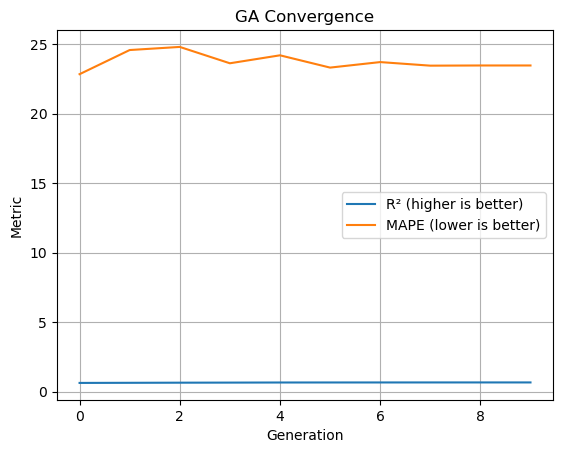


Final Validation Metrics:
R²: 0.656154863077787
MAPE: 22.278258204460144


In [167]:
best, fitness, r2_hist, mape_hist, val_r2, val_mape = run_ea()

import matplotlib.pyplot as plt

plt.figure()
plt.plot(r2_hist, label="R² (higher is better)")
plt.plot(mape_hist, label="MAPE (lower is better)")
plt.xlabel("Generation")
plt.ylabel("Metric")
plt.title("GA Convergence")
plt.legend()
plt.grid()
plt.show()

print("\nFinal Validation Metrics:")
print("R²:", val_r2)
print("MAPE:", val_mape)

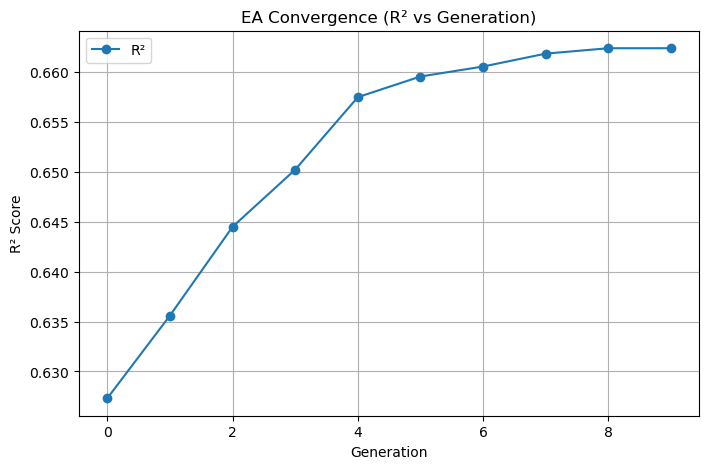

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(len(r2_hist)), r2_hist, marker='o', label="R²")

plt.xlabel("Generation")
plt.ylabel("R² Score")
plt.title("EA Convergence (R² vs Generation)")
plt.grid(True)
plt.legend()

plt.show()

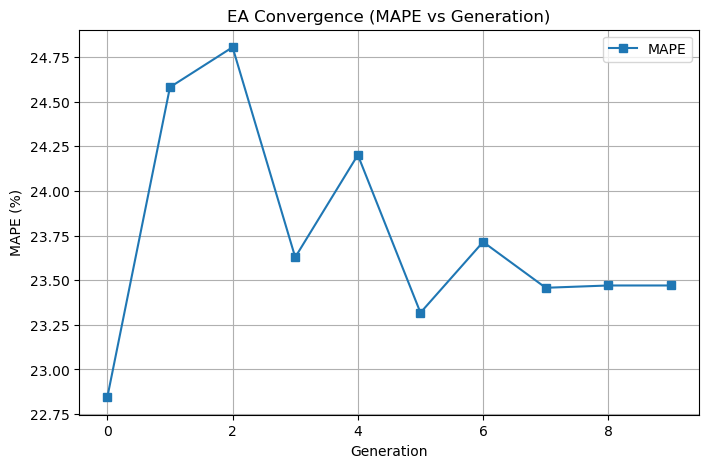

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(len(mape_hist)), mape_hist, marker='s', label="MAPE")

plt.xlabel("Generation")
plt.ylabel("MAPE (%)")
plt.title("EA Convergence (MAPE vs Generation)")
plt.grid(True)
plt.legend()

plt.show()

In [134]:
from tensorflow.keras.models import load_model
import json

model = load_model("results/best_model.h5")

with open("results/best_model_info.json") as f:
    info = json.load(f)